In [1]:
from wordcloud import WordCloud
from textblob import TextBlob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**1. Load Data**

In [7]:
file_path_after = '/content/drive/MyDrive/Analisis/dataset_levelearn_heart.csv'
df_qualitative = pd.read_csv(file_path_after, encoding="latin-1", sep=",")

qualitative_cols = ['Qualitative_Q1', 'Qualitative_Q2', 'Qualitative_Q3', 'Qualitative_Q4']
display(df_qualitative[qualitative_cols].head(10))

,Qualitative_Q1,Qualitative_Q2,Qualitative_Q3,Qualitative_Q4
0,"badge, saya terdorong untuk mengumpulkan lebih...",tidak,berguna semua,lebih terdorong setelah gamifikasi di terapkan
1,Elemen dashboard karena membuat saya ingin men...,Tidak,Tidak,Menjadi lebih rajin karena belajar sambil berm...
2,Leadboard,Tidak,Tidak ada,Sangat membantu dalam meningkatkan semangat be...
3,streak karena menantang,tidak,tidak,sesudah membjat lebih belajar karena ada metod...
4,Streak,Tidak,Menurut saya semuanya berguna dan bermanfaat. ...,"Karena gamifikasi yang diterapkan, saya merasa..."
5,Adanya sistwm rank,Tidak,"Ada, fitur ranknya jadi siapa yang cepat menja...",Lebih menarik dan tertantang
6,elemen leaderboard jadi memotifasi saya dalam ...,"Sudah baik, tidak usah",Semua Baik,Menjadi lebih mudah memahami
7,Materi lebih ringkas(to the point) jadi lebih ...,Tidak,ga ada,sebelum menggunakan gamifikasi pembelajaran su...
8,Poin karena seolah punya uang,Tidak,Tidak,Lebih seru dengan gamifikasi
9,"Ranking, karena memberi rasa kompetitif",Tidak,Tidak,Saya lebih senang menggunakan aplikasi belajar...


**2. Qualitative Analysis using Word Cloud**

In [19]:
def generate_word_cloud(text_data, title):
    # Membuat Word Cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(text_data))

    # Visualisasi Word Cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

**3. Qualitative Analysis using Sentiment Analysis**


ANALISIS UNTUK: Qualitative_Q1


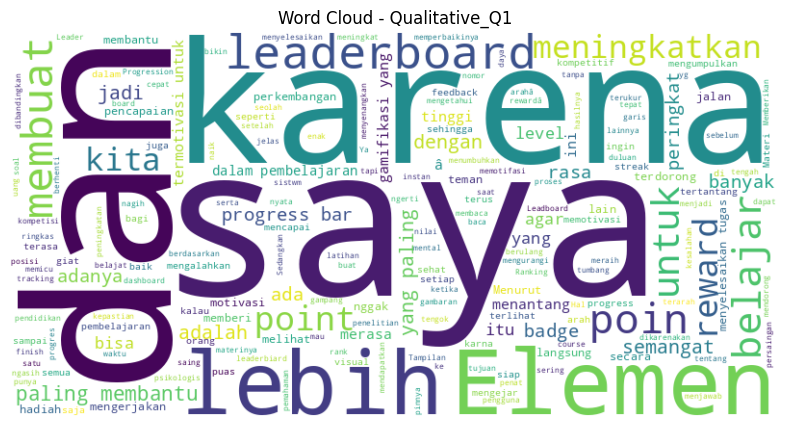

Rata-rata Skor Sentimen: -0.0123 (Negatif)

ANALISIS UNTUK: Qualitative_Q2


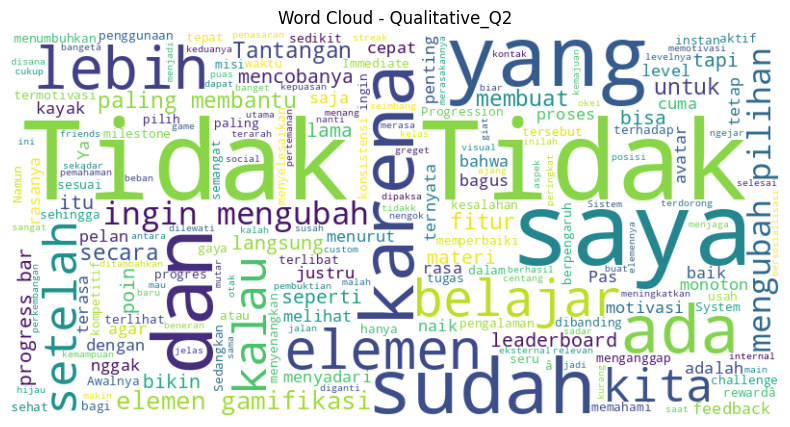

Rata-rata Skor Sentimen: -0.0015 (Negatif)

ANALISIS UNTUK: Qualitative_Q3


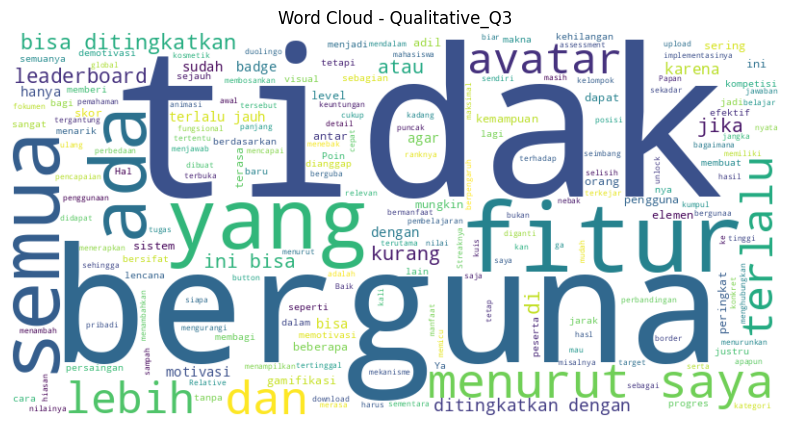

Rata-rata Skor Sentimen: 0.0000 (Netral)

ANALISIS UNTUK: Qualitative_Q4


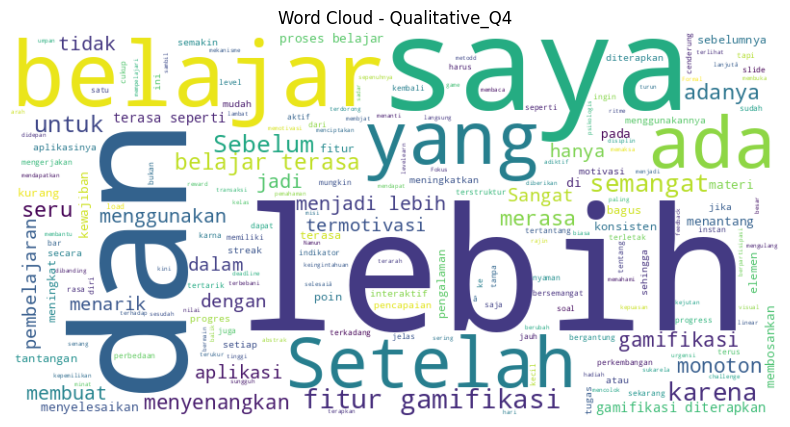

Rata-rata Skor Sentimen: -0.0014 (Negatif)


In [25]:
questions = ['Qualitative_Q1', 'Qualitative_Q2', 'Qualitative_Q3', 'Qualitative_Q4']

for question in questions:
    print(f"\n" + "="*50)
    print(f"ANALISIS UNTUK: {question}")
    print("="*50)

    valid_data = df_qualitative[question].dropna()

    if not valid_data.empty:
        generate_word_cloud(valid_data, f'Word Cloud - {question}')
        avg_sentiment = analyze_sentiment(valid_data)

        status = "Positif" if avg_sentiment > 0 else "Negatif" if avg_sentiment < 0 else "Netral"
        print(f'Rata-rata Skor Sentimen: {avg_sentiment:.4f} ({status})')
    else:
        print(f"Tidak ada data untuk {question}")

In [28]:
for question in questions:
    print(f"\n" + "="*80)
    print(f"--- VERIFIKASI JAWABAN SKOR TERENDAH (SISTEM) UNTUK: {question} ---")
    print("="*80)

    # Ambil data kualitatif dan bersihkan dari nilai kosong
    temp_df = df_qualitative[[question]].dropna()

    # Hitung skor sentimen menggunakan TextBlob
    temp_df['Sentiment_Score'] = temp_df[question].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

    display(temp_df.sort_values(by='Sentiment_Score').head(5))


--- VERIFIKASI JAWABAN SKOR TERENDAH (SISTEM) UNTUK: Qualitative_Q1 ---


,Qualitative_Q1,Sentiment_Score
5,Adanya sistwm rank,-0.80
23,belajar itu sering bikin penat dan merasa ngga...,-0.05
2,Leadboard,0.00
0,"badge, saya terdorong untuk mengumpulkan lebih...",0.00
3,streak karena menantang,0.00



--- VERIFIKASI JAWABAN SKOR TERENDAH (SISTEM) UNTUK: Qualitative_Q2 ---


,Qualitative_Q2,Sentiment_Score
23,"kalau cuma nengok progress bar yang jalan, lam...",-0.116667
0,tidak,0.000000
2,Tidak,0.000000
1,Tidak,0.000000
4,Tidak,0.000000



--- VERIFIKASI JAWABAN SKOR TERENDAH (SISTEM) UNTUK: Qualitative_Q3 ---


,Qualitative_Q3,Sentiment_Score
0,berguna semua,0.0
1,Tidak,0.0
2,Tidak ada,0.0
3,tidak,0.0
4,Menurut saya semuanya berguna dan bermanfaat. ...,0.0



--- VERIFIKASI JAWABAN SKOR TERENDAH (SISTEM) UNTUK: Qualitative_Q4 ---


,Qualitative_Q4,Sentiment_Score
15,Saya menjadi lebih semangat karena ada fitur f...,-0.400
38,Pengalaman sebelumnya masih sangat flat menggu...,-0.025
2,Sangat membantu dalam meningkatkan semangat be...,0.000
0,lebih terdorong setelah gamifikasi di terapkan,0.000
4,"Karena gamifikasi yang diterapkan, saya merasa...",0.000
